In [12]:

import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import json

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.word2vec_pytorch import Word2VecDataset, Word2VecPytorch, Word2VecPytorchTrainer
from src.data_pipeline import load_corpus, generate_training_data

In [13]:
id2word = {0: "phòng_trọ", 1: "máy_lạnh", 2: "giá_rẻ", 3: "sinh_viên", 4: "căn_hộ"}

training_data = [
    (0, 1), (1, 0), (0, 2), (2, 0), (0, 3), (3, 0),
    (4, 1), (1, 4), (4, 2), (2, 4)
]

dataset = Word2VecDataset(training_data)
dataloader = DataLoader(dataset, batch_size=5, shuffle=True)
model = Word2VecPytorch(vocab_size=5, embedding_dim=2)
trainer=Word2VecPytorchTrainer(model)
trainer.train(dataloader, epochs=100, learning_rate=0.05)

print("TÌM TỪ ĐỒNG NGHĨA VỚI 'phòng_trọ'")
similar_words = model.get_similar_words(word_id=0, top=3)
for idx, sim_score in similar_words:
    print(f" -> Từ liên quan: {id2word[idx]} (Độ tương đồng: {sim_score*100:.1f}%)")

Epoch 001/100 | Loss: 1.6343
Epoch 010/100 | Loss: 1.0308
Epoch 020/100 | Loss: 0.8148
Epoch 030/100 | Loss: 0.7716
Epoch 040/100 | Loss: 0.7618
Epoch 050/100 | Loss: 0.7606
Epoch 060/100 | Loss: 0.7525
Epoch 070/100 | Loss: 0.7579
Epoch 080/100 | Loss: 0.7581
Epoch 090/100 | Loss: 0.7511
Epoch 100/100 | Loss: 0.7534
TÌM TỪ ĐỒNG NGHĨA VỚI 'phòng_trọ'
 -> Từ liên quan: căn_hộ (Độ tương đồng: 52.6%)
 -> Từ liên quan: sinh_viên (Độ tương đồng: -56.7%)
 -> Từ liên quan: giá_rẻ (Độ tương đồng: -99.3%)


In [14]:
corpus = load_corpus("../data/processed/toy_corpus.txt")
with open('../data/processed/vocab.json','r',encoding='utf-8') as f:
    vocab=json.load(f)
word2id=vocab['word2id']
training_data=generate_training_data(corpus,word2id)

In [15]:
len(word2id)

1975

In [27]:
dataset = Word2VecDataset(training_data)
vocab_size=len(word2id)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
model = Word2VecPytorch(vocab_size=vocab_size, embedding_dim=30)
trainer=Word2VecPytorchTrainer(model)
trainer.train(dataloader, epochs=500, learning_rate=0.001)

Epoch 001/500 | Loss: 7.6228
Epoch 010/500 | Loss: 5.6508
Epoch 020/500 | Loss: 4.8669
Epoch 030/500 | Loss: 4.4377
Epoch 040/500 | Loss: 4.1828
Epoch 050/500 | Loss: 4.0230
Epoch 060/500 | Loss: 3.9142
Epoch 070/500 | Loss: 3.8367
Epoch 080/500 | Loss: 3.7801
Epoch 090/500 | Loss: 3.7342
Epoch 100/500 | Loss: 3.6987
Epoch 110/500 | Loss: 3.6700
Epoch 120/500 | Loss: 3.6463
Epoch 130/500 | Loss: 3.6267
Epoch 140/500 | Loss: 3.6083
Epoch 150/500 | Loss: 3.5944
Epoch 160/500 | Loss: 3.5802
Epoch 170/500 | Loss: 3.5677
Epoch 180/500 | Loss: 3.5576
Epoch 190/500 | Loss: 3.5481
Epoch 200/500 | Loss: 3.5389
Epoch 210/500 | Loss: 3.5316
Epoch 220/500 | Loss: 3.5247
Epoch 230/500 | Loss: 3.5181
Epoch 240/500 | Loss: 3.5136
Epoch 250/500 | Loss: 3.5072
Epoch 260/500 | Loss: 3.5025
Epoch 270/500 | Loss: 3.4966
Epoch 280/500 | Loss: 3.4929
Epoch 290/500 | Loss: 3.4886
Epoch 300/500 | Loss: 3.4848
Epoch 310/500 | Loss: 3.4807
Epoch 320/500 | Loss: 3.4762
Epoch 330/500 | Loss: 3.4740
Epoch 340/500 

[7.622818770727895,
 7.348406444615473,
 7.0304684824356505,
 6.698975522883767,
 6.42457898389186,
 6.213312775218461,
 6.041818524024914,
 5.894994971561638,
 5.766562888225778,
 5.650805314725212,
 5.543830396804645,
 5.445886755092612,
 5.356404826656531,
 5.272973445785226,
 5.194392565774609,
 5.12000932652286,
 5.0501009836052715,
 4.985604827913816,
 4.924709163525707,
 4.8669441492974626,
 4.813514954585494,
 4.760813224907828,
 4.71217544547425,
 4.665981291694724,
 4.623121274985196,
 4.582038494217215,
 4.543070517142442,
 4.5049436195365296,
 4.470886149622709,
 4.437746294116356,
 4.406447715429714,
 4.3766508962371695,
 4.348433992002747,
 4.319378343050732,
 4.294475742344208,
 4.270233750085851,
 4.247389747566075,
 4.224124034074161,
 4.204657834240479,
 4.182754325557734,
 4.1636008696216225,
 4.14558612347679,
 4.128139337247185,
 4.110440796446337,
 4.094779372472742,
 4.079091700827844,
 4.06277144186955,
 4.04954516398469,
 4.03505516927649,
 4.022996293288328,
 

In [28]:
id2word = {int(k): v for k, v in vocab['id2word'].items()}


In [42]:
print("TÌM TỪ ĐỒNG NGHĨA VỚI 'ổn_định'")
similar_words = model.get_similar_words(word_id=436, top=3)
for idx, sim_score in similar_words:
    print(f" -> Từ liên quan: {id2word[idx]} (Độ tương đồng: {sim_score*100:.1f}%)")

TÌM TỪ ĐỒNG NGHĨA VỚI 'ổn_định'
 -> Từ liên quan: đảm_bảo (Độ tương đồng: 68.1%)
 -> Từ liên quan: dài_hạn (Độ tương đồng: 66.2%)
 -> Từ liên quan: ngắn_hạn (Độ tương đồng: 64.0%)


Đang trích xuất ma trận W1 và giảm chiều dữ liệu...


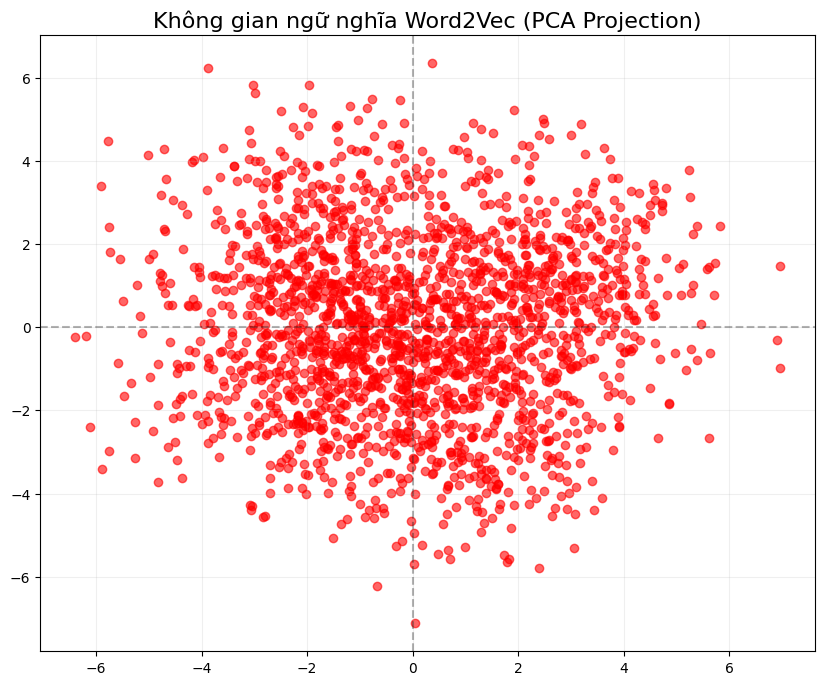

In [44]:
def visualize_embeddings(model, id2word):
    embeddings = model.W1.weight.detach().cpu().numpy()
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    plt.figure(figsize=(10, 8))

    for word_id, word in id2word.items():
        x, y = embeddings_2d[word_id]
        plt.scatter(x, y, color='red', alpha=0.6)
        #plt.text(x + 0.02, y + 0.02, word, fontsize=12)

    plt.title("Không gian ngữ nghĩa Word2Vec (PCA Projection)", fontsize=16)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.2)
    plt.show()

visualize_embeddings(model, id2word)